In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

In [3]:
testnum = "Test-4"
model_dir = f"{testnum}/models"
plot_dir = f"{testnum}/plots"

In [4]:
# Create directory to save results
os.makedirs(testnum, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

In [5]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape the data
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers, callbacks

from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.optimizers.schedules import CosineDecay

# Advanced augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.2
)
datagen.fit(x_train)

# Learning rate scheduler
lr_schedule = CosineDecay(initial_learning_rate=0.001, decay_steps=40*len(x_train)//64)

In [7]:
# Build VGG-style model
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.5),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile
model.compile(optimizer=RMSprop(learning_rate=lr_schedule),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = callbacks.EarlyStopping(patience=7, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)


In [10]:
history = model.fit(datagen.flow(x_train, y_train_cat, batch_size=64),
                    validation_data=(x_test, y_test_cat),
                    epochs=50,
                    callbacks=[early_stop])

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 216s 230ms/step - accuracy: 0.0995 - loss: 2.3132 - val_accuracy: 0.1001 - val_loss: 1939.0200
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 215s 230ms/step - accuracy: 0.0990 - loss: 2.3115 - val_accuracy: 0.1005 - val_loss: 166.2725
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 349s 372ms/step - accuracy: 0.1004 - loss: 2.3091 - val_accuracy: 0.0633 - val_loss: 223.6550
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 385s 410ms/step - accuracy: 0.1012 - loss: 2.3072 - val_accuracy: 0.1009 - val_loss: 285.6490
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 383s 408ms/step - accuracy: 0.0991 - loss: 2.3068 - val_accuracy: 0.0990 - val_loss: 112.9455
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 390s 416ms/step - accuracy: 0.1021 - loss: 2.3045 - val_accuracy: 0.0981 - val_loss: 491.7007
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 410s 436ms/step - accuracy: 0.1016 - loss: 2.3055 - val_accuracy: 0.0998 - val_loss: 741.7897
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 408s 435ms/step - acc

313/313 - 8s - 24ms/step - accuracy: 0.0990 - loss: 112.9455



🏁 Final Test Accuracy: 9.90%


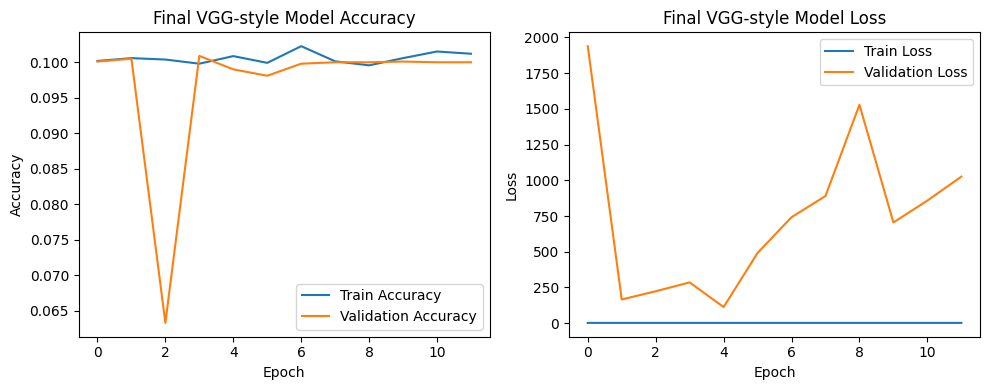

In [11]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\n🏁 Final Test Accuracy: {test_acc * 100:.2f}%")

# Save model
model.save(f"{model_dir}/vgg_fashion_mnist_model.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Final VGG-style Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Final VGG-style Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{plot_dir}/vgg_fashion_mnist_training_plot.png")
plt.show()
